# E-Commerce Market Basket Analysis using Apriori Algorithm

## Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [72]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Preprocessing & Cleaning

In [73]:
df = df.dropna(subset=['CustomerID', 'Description'])
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]
df = df[df['Quantity'] > 0]

## Constructing the Transaction Basket Matrix

In [74]:
top_products = df['Description'].value_counts().head(100).index
df_filtered = df[df['Description'].isin(top_products)]

basket = (df_filtered[df_filtered['Country'] == 'United Kingdom']
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().fillna(0))
basket_sets = basket.map(lambda x: 1 if x > 0 else 0)
basket_sets = basket_sets[(basket_sets.sum(axis=1) >= 2)]

## Apriori Algorithm & Frequent Itemsets Mining

In [75]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket_sets.astype(bool),min_support=0.02,use_colnames=True,low_memory=True,max_len=3)
frequent_itemsets = frequent_itemsets.sort_values( by='support',   ascending=False)
frequent_itemsets.head(10)

,support,itemsets
94,0.164505,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
37,0.130233,frozenset({JUMBO BAG RED RETROSPOT})
76,0.119396,frozenset({REGENCY CAKESTAND 3 TIER})
6,0.112171,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
64,0.110504,frozenset({PARTY BUNTING})
50,0.103001,frozenset({LUNCH BAG RED RETROSPOT})
44,0.091052,frozenset({LUNCH BAG BLACK SKULL.})
83,0.089848,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
62,0.082438,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS })
25,0.082345,frozenset({HEART OF WICKER SMALL})


## Extracting Association Rules

In [76]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
275,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RE...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.021304,0.716511,16.015428
278,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RE...",0.021304,0.476190,16.015428
65,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031586,0.716387,16.012649
68,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.031586,0.706004,16.012649
67,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.031586,0.562706,15.861558
66,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031586,0.890339,15.861558
276,"frozenset({PINK REGENCY TEACUP AND SAUCER, REG...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.021304,0.867925,15.462233
277,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, REG...",0.021304,0.379538,15.462233
29,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.037421,0.836439,14.901311
28,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.037421,0.666667,14.901311


## Visualizing Association Rules

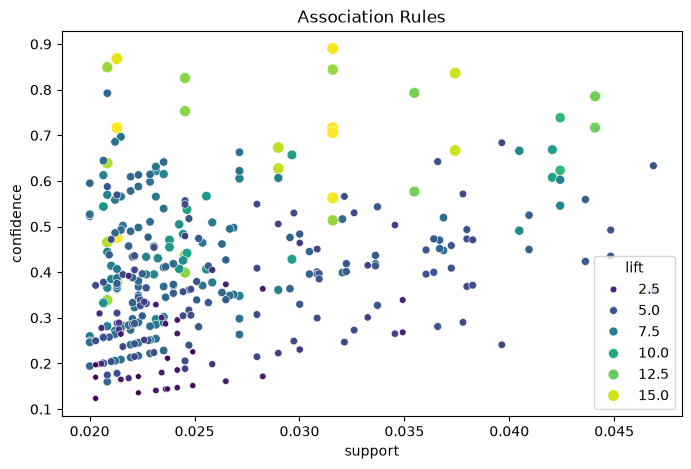

In [77]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='viridis')
plt.title('Association Rules')
plt.show()